In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

with open('../models/rf_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/feature_names.pkl', 'rb') as f:
    features = pickle.load(f)

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("Test set shape:", X_test.shape)
print("Class distribution:\n", y_test.value_counts())

Test set shape: (23723, 17)
Class distribution:
 is_malicious
0    22446
1     1277
Name: count, dtype: int64


In [3]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

tp_mask = (y_test == 1) & (y_pred == 1)
fp_mask = (y_test == 0) & (y_pred == 1)
fn_mask = (y_test == 1) & (y_pred == 0)
tn_mask = (y_test == 0) & (y_pred == 0)

print(f"True  Positives (correctly flagged threats): {tp_mask.sum()}")
print(f"False Positives (normal flagged as threat):  {fp_mask.sum()}")
print(f"False Negatives (missed threats):            {fn_mask.sum()}")
print(f"True  Negatives (correctly cleared normal):  {tn_mask.sum()}")
print(f"\nTotal test records: {len(y_test)}")

True  Positives (correctly flagged threats): 996
False Positives (normal flagged as threat):  910
False Negatives (missed threats):            281
True  Negatives (correctly cleared normal):  21536

Total test records: 23723


In [4]:
tp_records = X_test[tp_mask].copy()
tp_records['actual']     = 1
tp_records['predicted']  = 1
tp_records['confidence'] = y_proba[tp_mask]
tp_records = tp_records.sort_values('confidence', ascending=False)

print("TOP 5 TRUE POSITIVES (Correctly Detected Threats)\n")
display_cols = ['total_files_burned','total_printed_pages',
                'num_printed_pages_off_hours','entry_during_weekend',
                'burned_from_other','confidence']
print(tp_records[display_cols].head(5).to_string())

TOP 5 TRUE POSITIVES (Correctly Detected Threats)

       total_files_burned  total_printed_pages  num_printed_pages_off_hours  entry_during_weekend  burned_from_other  confidence
2502                  117                    0                            0                     0                  0    0.993916
11634                  75                  121                           46                     0                  1    0.993489
11046                  94                   67                           42                     0                  0    0.993002
21206                  96                   25                           13                     0                  1    0.992340
23286                  70                   62                           42                     0                  0    0.992329


In [5]:
fp_records = X_test[fp_mask].copy()
fp_records['actual']     = 0
fp_records['predicted']  = 1
fp_records['confidence'] = y_proba[fp_mask]
fp_records = fp_records.sort_values('confidence', ascending=False)

print("TOP 5 FALSE POSITIVES (Normal Employees Wrongly Flagged)\n")
print(fp_records[display_cols].head(5).to_string())

TOP 5 FALSE POSITIVES (Normal Employees Wrongly Flagged)

       total_files_burned  total_printed_pages  num_printed_pages_off_hours  entry_during_weekend  burned_from_other  confidence
7374                   82                    0                            0                     0                  0    0.988902
14916                  68                    0                            0                     0                  0    0.984019
11592                 120                    0                            0                     0                  0    0.981811
3134                    0                  128                           40                     0                  0    0.980736
5847                  101                    0                            0                     0                  0    0.977968


In [6]:
fn_records = X_test[fn_mask].copy()
fn_records['actual']     = 1
fn_records['predicted']  = 0
fn_records['confidence'] = y_proba[fn_mask]
fn_records = fn_records.sort_values('confidence', ascending=False)

print("TOP 5 FALSE NEGATIVES (Missed Threats) \n")
print(fn_records[display_cols].head(5).to_string())

TOP 5 FALSE NEGATIVES (Missed Threats) 

       total_files_burned  total_printed_pages  num_printed_pages_off_hours  entry_during_weekend  burned_from_other  confidence
11345                   8                    0                            0                     1                  0    0.498424
15277                  54                    0                            0                     1                  0    0.498250
8869                    8                    0                            0                     0                  0    0.497786
11729                   0                    0                            0                     0                  0    0.497554
22002                   0                    0                            0                     0                  0    0.495686


In [8]:
print("FALSE NEGATIVE ANALYSIS \n")
print("Avg feature values — False Negatives vs True Positives:\n")

fn_avg = X_test[fn_mask][features].mean()
tp_avg = X_test[tp_mask][features].mean()

comparison = pd.DataFrame({
    'False Negatives (missed)': fn_avg,
    'True Positives (caught)':  tp_avg,
    'Difference': fn_avg - tp_avg
}).round(3)

print(comparison.sort_values('Difference').to_string())

FALSE NEGATIVE ANALYSIS 

Avg feature values — False Negatives vs True Positives:

                             False Negatives (missed)  True Positives (caught)  Difference
total_files_burned                              5.662                   56.623     -50.962
total_printed_pages                            14.530                   28.656     -14.125
num_printed_pages_off_hours                     0.623                    4.070      -3.448
employee_seniority_years                       11.751                   14.173      -2.422
num_unique_campus                               0.754                    0.882      -0.127
burned_from_other                               0.025                    0.128      -0.103
num_entries                                     0.950                    1.042      -0.092
employee_classification                         2.000                    2.087      -0.087
hostility_country_level                         0.000                    0.065      -0.065
is_abro

In [9]:
print("FALSE POSITIVE ANALYSIS\n")
print("Avg feature values — False Positives vs True Negatives:\n")

fp_avg = X_test[fp_mask][features].mean()
tn_avg = X_test[tn_mask][features].mean()

comparison2 = pd.DataFrame({
    'False Positives (wrongly flagged)': fp_avg,
    'True Negatives (correctly cleared)': tn_avg,
    'Difference': fp_avg - tn_avg
}).round(3)

print(comparison2.sort_values('Difference', ascending=False).to_string())

FALSE POSITIVE ANALYSIS

Avg feature values — False Positives vs True Negatives:

                             False Positives (wrongly flagged)  True Negatives (correctly cleared)  Difference
total_printed_pages                                     50.792                              11.117      39.675
employee_seniority_years                                14.057                              12.237       1.820
num_printed_pages_off_hours                              1.749                               0.319       1.431
total_files_burned                                       8.592                               7.182       1.410
num_entries                                              0.988                               0.725       0.263
num_unique_campus                                        0.803                               0.577       0.227
employee_department                                      5.645                               5.562       0.083
employee_classification       

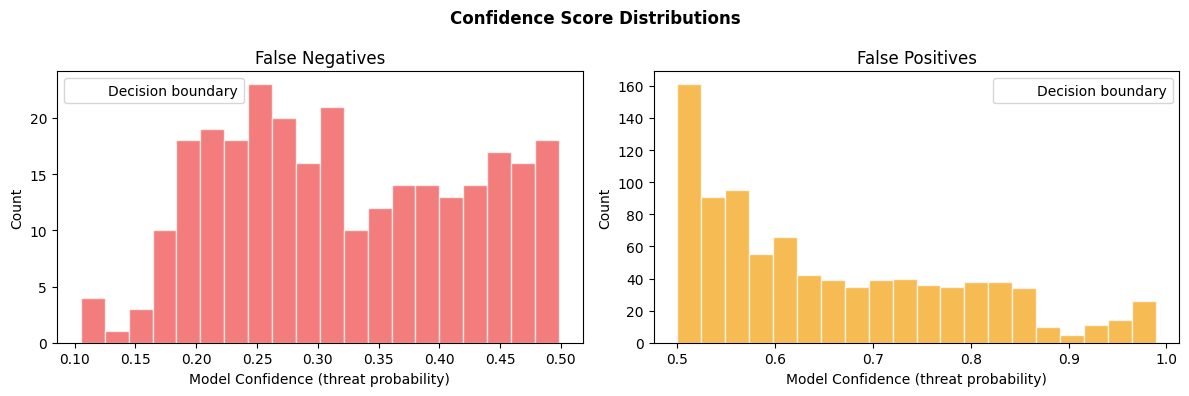

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confidence Score Distributions', fontweight='bold')

axes[0].hist(y_proba[fn_mask], bins=20, color='#ef4444', alpha=0.7, edgecolor='white')
axes[0].set_title('False Negatives')
axes[0].set_xlabel('Model Confidence (threat probability)')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='black', linestyle='', label='Decision boundary')
axes[0].legend()

axes[1].hist(y_proba[fp_mask], bins=20, color='#f59e0b', alpha=0.7, edgecolor='white')
axes[1].set_title('False Positives')
axes[1].set_xlabel('Model Confidence (threat probability)')
axes[1].set_ylabel('Count')
axes[1].axvline(0.5, color='black', linestyle='', label='Decision boundary')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/confidence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("THRESHOLD SENSITIVITY ANALYSIS\n")
print(f"{'Threshold':<12} {'TP':<8} {'FP':<8} {'FN':<8} {'Precision':<12} {'Recall':<10} {'F1':<8}")
print("-" * 60)

from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    tp = ((y_test==1) & (y_pred_t==1)).sum()
    fp = ((y_test==0) & (y_pred_t==1)).sum()
    fn = ((y_test==1) & (y_pred_t==0)).sum()
    p  = precision_score(y_test, y_pred_t, zero_division=0)
    r  = recall_score(y_test, y_pred_t, zero_division=0)
    f  = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:<12} {tp:<8} {fp:<8} {fn:<8} {p:<12.4f} {r:<10.4f} {f:<8.4f}")

THRESHOLD SENSITIVITY ANALYSIS

Threshold    TP       FP       FN       Precision    Recall     F1      
------------------------------------------------------------
0.3          1145     3851     132      0.2292       0.8966     0.3651  
0.4          1074     2031     203      0.3459       0.8410     0.4902  
0.5          996      910      281      0.5226       0.7800     0.6258  
0.6          893      503      384      0.6397       0.6993     0.6682  
0.7          814      318      463      0.7191       0.6374     0.6758  


In [7]:
pd.DataFrame({
    'scenario':   ['True Positive']*5 + ['False Positive']*5 + ['False Negative']*5,
    'actual':     [1]*5 + [0]*5 + [1]*5,
    'predicted':  [1]*5 + [1]*5 + [0]*5,
    'confidence': list(tp_records['confidence'].head(5).round(3)) +
                  list(fp_records['confidence'].head(5).round(3)) +
                  list(fn_records['confidence'].head(5).round(3)),
}).to_csv('../data/testing_scenarios.csv', index=False)